In [1]:
import pandas as pd

print("We are officially doing data science 😌")



We are officially doing data science 😌


In [2]:
df = pd.read_csv('ProviderFraud.csv')
df.head()

,Unnamed: 0,BeneID,DOB,Gender,Race,RenalDiseaseIndicator,State,County,ChronicCond_Alzheimer,ChronicCond_Heartfailure,...,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Patient_Age_Year,Patient_Age_Month,Dead_or_Alive,AGE,AGE_groups
0,0,BENE11001,1943-01-01,1,1,0,39,230,1,2,...,1,36000,3204,60,70,1943,1,0,67.0,Old
1,1,BENE11002,1936-09-01,0,1,0,39,280,2,2,...,2,0,0,30,50,1936,9,0,73.3,Old
2,2,BENE11003,1936-08-01,1,1,0,52,590,1,2,...,2,0,0,90,40,1936,8,0,73.4,Old
3,3,BENE11004,1922-07-01,1,1,0,39,270,1,1,...,2,0,0,1810,760,1922,7,0,87.5,Very Old
4,4,BENE11005,1935-09-01,1,1,0,24,680,2,2,...,2,0,0,1790,1200,1935,9,0,74.3,Old


In [3]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,BeneID,DOB,Gender,Race,RenalDiseaseIndicator,State,County,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,...,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Patient_Age_Year,Patient_Age_Month,Dead_or_Alive,AGE,AGE_groups
0,BENE11001,1943-01-01,1,1,0,39,230,1,2,1,...,1,36000,3204,60,70,1943,1,0,67.0,Old
1,BENE11002,1936-09-01,0,1,0,39,280,2,2,2,...,2,0,0,30,50,1936,9,0,73.3,Old
2,BENE11003,1936-08-01,1,1,0,52,590,1,2,2,...,2,0,0,90,40,1936,8,0,73.4,Old
3,BENE11004,1922-07-01,1,1,0,39,270,1,1,2,...,2,0,0,1810,760,1922,7,0,87.5,Very Old
4,BENE11005,1935-09-01,1,1,0,24,680,2,2,2,...,2,0,0,1790,1200,1935,9,0,74.3,Old


In [4]:
df['DOB'] = pd.to_datetime(df['DOB'])

from datetime import datetime
current_year = datetime.now().year

df['Age'] = current_year - df['DOB'].dt.year

df[['DOB', 'Age']].head()

,DOB,Age
0,1943-01-01,83
1,1936-09-01,90
2,1936-08-01,90
3,1922-07-01,104
4,1935-09-01,91


In [5]:
df['Age_Group'] = pd.cut(df['Age'],
                        bins=[0, 50, 65, 75, 85, 100],
                        labels=['Under 50', '50-65', '65-75', '75-85', '85+'])

df[['Age', 'Age_Group']].head()

,Age,Age_Group
0,83,75-85
1,90,85+
2,90,85+
3,104,NaN
4,91,85+


In [7]:
df = df[df['Age'] < 100]

In [8]:
df['DOB'] = pd.to_datetime(df['DOB'])

from datetime import datetime
current_year = datetime.now().year

df['Age'] = current_year - df['DOB'].dt.year

df[['DOB', 'Age']].head()

df = df[df['Age'] < 100]

In [9]:
df['Age'].max()

np.int32(99)

In [10]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 50, 65, 75, 85, 100],
    labels=['Under 50', '50-65', '65-75', '75-85', '85+']
)

df[['Age', 'Age_Group']].head()

,Age,Age_Group
0,83,75-85
1,90,85+
2,90,85+
4,91,85+
5,50,Under 50


In [11]:
age_cost = df.groupby('Age_Group')['InscClaimAmtReimbursed'].mean()
age_cost

/var/folders/10/gjbndssd0v5b_1bgzn8jzqh80000gp/T/ipykernel_74767/2142466790.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_cost = df.groupby('Age_Group')['InscClaimAmtReimbursed'].mean()


KeyError: 'Column not found: InscClaimAmtReimbursed'

In [12]:
df.columns.tolist()

['BeneID',
 'DOB',
 'Gender',
 'Race',
 'RenalDiseaseIndicator',
 'State',
 'County',
 'ChronicCond_Alzheimer',
 'ChronicCond_Heartfailure',
 'ChronicCond_KidneyDisease',
 'ChronicCond_Cancer',
 'ChronicCond_ObstrPulmonary',
 'ChronicCond_Depression',
 'ChronicCond_Diabetes',
 'ChronicCond_IschemicHeart',
 'ChronicCond_Osteoporasis',
 'ChronicCond_rheumatoidarthritis',
 'ChronicCond_stroke',
 'IPAnnualReimbursementAmt',
 'IPAnnualDeductibleAmt',
 'OPAnnualReimbursementAmt',
 'OPAnnualDeductibleAmt',
 'Patient_Age_Year',
 'Patient_Age_Month',
 'Dead_or_Alive',
 'AGE',
 'AGE_groups',
 'Age',
 'Age_Group']

In [13]:
df['Total_Reimbursement'] = df['IPAnnualReimbursementAmt'] + df['OPAnnualReimbursementAmt']

In [14]:
age_cost = df.groupby('Age_Group')['Total_Reimbursement'].mean()
age_cost

/var/folders/10/gjbndssd0v5b_1bgzn8jzqh80000gp/T/ipykernel_74767/1835277564.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_cost = df.groupby('Age_Group')['Total_Reimbursement'].mean()


Age_Group
Under 50    4503.267457
50-65       5144.841845
65-75       5171.532629
75-85       4728.711719
85+         4783.662771
Name: Total_Reimbursement, dtype: float64

Matplotlib is building the font cache; this may take a moment.


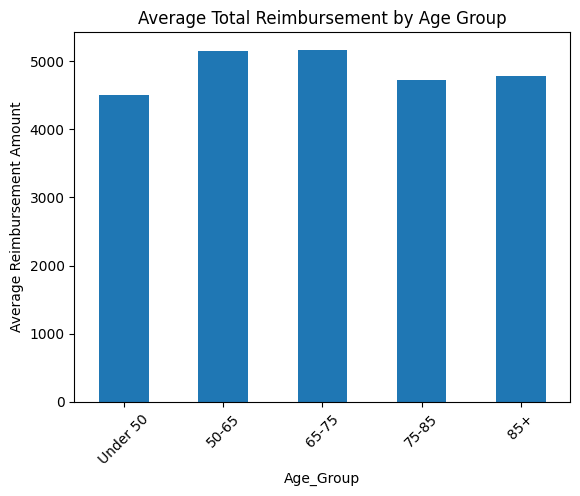

In [15]:
import matplotlib.pyplot as plt

age_cost.plot(kind='bar')
plt.title('Average Total Reimbursement by Age Group')
plt.ylabel('Average Reimbursement Amount')
plt.xticks(rotation=45)
plt.show()

## Key Insight

Average total reimbursement was lowest for beneficiaries under 50 and highest for the 50–65 and 65–75 groups. In this dataset, reimbursement did not increase steadily across every age band, suggesting that healthcare cost patterns may be influenced by factors beyond age alone.

In [22]:
diabetes_cost = df.groupby('ChronicCond_Diabetes')['Total_Reimbursement'].mean()
diabetes_cost

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


ChronicCond_Diabetes
1    6381.900820
2    2589.432983
Name: Total_Reimbursement, dtype: float64

In [24]:
df['Diabetes_Label'] = df['ChronicCond_Diabetes'].map({
    1: 'Diabetes',
    2: 'No Diabetes'
})

diabetes_cost = df.groupby('Diabetes_Label')['Total_Reimbursement'].mean()
diabetes_cost

Diabetes_Label
Diabetes       6381.900820
No Diabetes    2589.432983
Name: Total_Reimbursement, dtype: float64

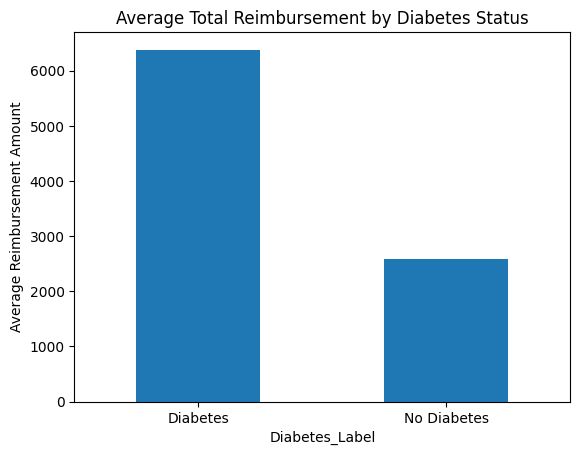

In [25]:
diabetes_cost.plot(kind='bar')
plt.title('Average Total Reimbursement by Diabetes Status')
plt.ylabel('Average Reimbursement Amount')
plt.xticks(rotation=0)
plt.show()

## Diabetes Insight

Beneficiaries with diabetes had significantly higher average total reimbursement compared to those without diabetes in this dataset, indicating that chronic conditions are a major driver of healthcare costs.